# Resonator punchout

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import SESSIONS
from qblox_lab.experiments.cal04_resonator_punchout import ResonatorPunchout

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # Use None if no flux bias needed
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
FREQUENCY_CENTER = None
FREQUENCY_WIDTH = 1e6
FREQUENCY_POINTS = 101
AMPLITUDE_START = 0.01
AMPLITUDE_STOP = 0.30
AMPLITUDE_POINTS = 21
REPETITIONS = 10

OUTPUT_ATTENUATION = 26
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_CALIBRATED_DEVICE = SESSION.device_config  # Use None if param persisting is not required

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ResonatorPunchout(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [4]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    amplitude_start=AMPLITUDE_START,
    amplitude_stop=AMPLITUDE_STOP,
    amplitude_points=AMPLITUDE_POINTS,
    repetitions=REPETITIONS,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 85kB
Dimensions:           (acq_index_S21_q1: 2121)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 17kB 5.011e+09 ... 5.012e+09
    amplitude_q1      (acq_index_S21_q1) float64 17kB 0.01 0.01 0.01 ... 0.3 0.3
  * acq_index_S21_q1  (acq_index_S21_q1) int64 17kB 0 1 2 3 ... 2118 2119 2120
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 34kB (0.00015771104097366...
Attributes:
    tuid:     20260825-043603-438-542493

## Analysis

In [5]:
results = experiment.analysis()
for qubit, result in results.items():
    total_shift = result.resonance_frequencies[-1] - result.resonance_frequencies[0]
    print(
        f"{qubit}: resonance moves from "
        f"{result.resonance_frequencies[0] / 1e9:.9f} GHz to "
        f"{result.resonance_frequencies[-1] / 1e9:.9f} GHz "
        f"(shift {total_shift / 1e6:.3f} MHz)"
    )

q1: resonance moves from 5.011835058 GHz to 5.011565058 GHz (shift -0.270 MHz)


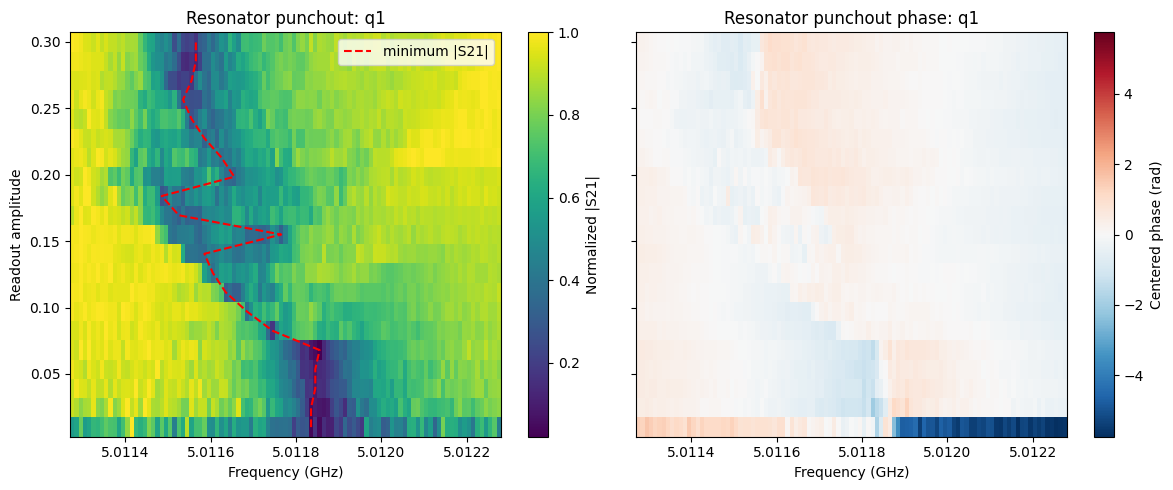

In [6]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [9]:
READOUT_AMPLITUDE_UPDATES = {"q1": 0.06} # Set the readout pulse amp

In [10]:
if READOUT_AMPLITUDE_UPDATES is not None:
    experiment.update_device(READOUT_AMPLITUDE_UPDATES)
    if SAVE_CALIBRATED_DEVICE is not None:
        saved_path = save_device_configuration(
            hardware_agent.quantum_device,
            SAVE_CALIBRATED_DEVICE,
        )
        print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()